In [1]:
# capstone project -- function 7 (6D), week N

import numpy as np
import warnings
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.spatial import Delaunay, ConvexHull
from scipy.stats import spearmanr

from bayes_tools import (
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_kappa_proposals, print_kappa_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 7

6D, 30 initial points plus 1 collected. **Using UCB with `kappa=0.25`, searching only the four informative axes** (x0, x3, x4, x5) with x1 and x2 held at the incumbent.

Proposal this week: **`[0.003829, 0.491672, 0.247422, 0.221119, 0.396477, 0.737016]`** (GP mean +1.3718, std 0.055; the current best is 1.36497).

This is a deliberately **small, local step** -- 0.06 from the incumbent. The reasoning for that is below, and it is a direct response to what last week's evaluation did.

There is no project-wide best approach; each function is decided from its own evidence.

## Read this first: last week's point has a sign problem, and it failed

The old week-1 sweep proposed, for function 7:

```
x_next: [ 0.273698  1.11042   1.04745   1.667513 -0.629585  1.119339]
```

**Negative x4** -- possible only because it called `initial_bounds(X, pad_fraction=1.0)` with no `lower_limit`, so the lower bounds ran below zero. The point recorded below is the same six magnitudes with **x4 flipped positive**, exactly as happened to function 4. So there is genuine ambiguity about where `y = 0.000309` was actually measured. The values recorded are the ones supplied.

And the result was **the worst of all 31 observations**. `y = 0.000309` against a range of 0.0027 to 1.365; it ranks 31st of 31. The proposal was an aggressive extrapolation -- **four of six** coordinates (x1, x2, x3, x5) beyond anything previously sampled -- and it landed in a dead region.

That is the mirror image of function 5, where extrapolating outward returned a 5.65x improvement. Same tooling, opposite lesson, which is precisely why the acquisition and step size are decided per function.

## The model saw it coming, which is reassuring

Fitted on the initial 30 points alone, the GP predicted that location at `+0.2055 +/- 0.3163` against an actual `+0.000309` -- a **-0.6 sigma** miss. The model correctly expected a mediocre value; it was the *proposal* that was bad, not the surrogate.

The kernel is also essentially unchanged by the new point: length-scales `[0.581, 10, 10, 0.196, 0.0988, 0.134]` became `[0.576, 10, 10, 0.195, 0.0981, 0.133]`. Compare function 4, where one observation tripled every length-scale. A stable, well-calibrated model is a model whose posterior mean can be leaned on -- which is what justifies a small exploitative step here.

## x1 and x2 are genuinely flat, so they are not searched

Both are pinned at the 10.0 ceiling **before and after** the new observation, and sweeping them moves the GP mean by almost nothing:

| axis | GP mean-variation across bounds | length-scale | spearman(y) |
|---|---|---|---|
| x0 | 0.988 | 0.576 | -0.238 |
| **x1** | **0.0060** | **10.0 (pinned)** | -0.177 |
| **x2** | **0.0074** | **10.0 (pinned)** | +0.200 |
| x3 | 1.278 | 0.195 | -0.177 |
| x4 | 1.356 | 0.098 | -0.448 |
| x5 | 1.225 | 0.133 | +0.079 |

x1 and x2 move the response by roughly **200x less** than the other four. That is a much clearer verdict than function 5's contested x3 (where the pre-outlier fit and the rank correlations disagreed with the ARD length-scales) -- here the pinning is stable across refits and the mean-variation confirms it, so holding them at the incumbent is safe rather than a judgement call.

The remaining four axes are comparable in influence (0.99 to 1.36), so there is **no single dominant axis** and no reduction to a 1D search of the kind used on functions 3 and 5.

## Why `kappa=0.25`, and why the step is small

Searching {x0, x3, x4, x5} with x1/x2 fixed:

| `kappa` | pred. mean | pred. std | on upper bound | on lower bound (x >= 0 floor) | dist from incumbent |
|---|---|---|---|---|---|
| 0 (= `exploit`) | +1.3734 | 0.043 | none | none | 0.041 |
| **0.25** | **+1.3718** | **0.055** | **none** | **none** | **0.060** |
| 0.5 | +1.3674 | 0.067 | none | x0 | 0.066 |
| 1.0 | +1.3490 | 0.091 | none | x0 | 0.075 |

`kappa=0.25` is the largest value that touches no bound at all, upper or lower, while still carrying a little exploration weight. (Lower-bound contact would not itself be disqualifying -- the lower bound of `0.0` is a real domain constraint, unlike the `pad_fraction`-derived upper bounds -- but there is no need to accept it when a slightly smaller `kappa` avoids it.)

The step is only 0.060 from the incumbent, and that is the intended behaviour on this function:

- Last week's large extrapolation returned the worst value on record. There is no evidence that pushing outward pays here.
- The model is well calibrated (-0.6 sigma), so its posterior mean near the incumbent is trustworthy.
- **The incumbent is a point the model cannot explain.** In leave-one-out, the worst-predicted observation is the incumbent itself: held out, it is predicted at `0.203 +/- 0.086` against a true `1.365` -- a roughly 13.5 sigma miss. The peak rests on a single unexplained measurement, so mapping its local neighbourhood is genuinely informative: it either confirms a real peak or reveals it as noise.

## What the backtest says

| config | mean regret | median regret |
|---|---|---|
| `exploit` | 0.676 | 0.602 |
| `ucb_k0.5` | 0.714 | 0.614 |
| `ucb_k1` | 0.718 | 0.614 |
| `pi` | 0.722 | 0.614 |
| `ucb_k2` | 0.732 | 0.614 |
| `ei` | 0.733 | 0.614 |
| `ucb_k5` | 0.816 | 0.675 |
| `max_var` | 0.871 | 0.675 |

It prefers exploitation, which agrees with the choice above -- but weakly, and it should not be leaned on. The metric scores recognition of points whose `y` is already known, which rewards ranking by posterior mean, so it favours `exploit` and low `kappa` on *every* function irrespective of what is appropriate (it ranked function 3's chosen config last). The whole field here spans 0.676 to 0.871 with six of eight medians identical at 0.614. Treat it as consistent with the conclusion, not as the reason for it.

## No y-scaling

`y` spans 0.000309 to 1.365, so a default `xi=0.01` is 0.73% of the spread -- inside the 0.1%-10% band where scaling is unnecessary. `kappa` is dimensionless regardless; the backtest's PI/EI rows use `xi` sized at 1% of the spread.

Note EI misbehaves here if `xi` is set too large: at 5% of the spread it abandons the peak entirely and proposes a region with predicted mean +0.228 (against the incumbent's 1.365), the same collapse onto its variance term seen on functions 4 and 8. Another reason UCB is the family of choice.

## Dimensionality-specific choices

- D=6, so `plot_2d_bo` doesn't apply -- the GP/acquisition view is **`plot_nd_slices`**. Expect the x1 and x2 panels to be flat lines; that is the model, not a plotting bug.
- `plot_bo_diagnostics` and `plot_sample_trajectory` hard-code a 2D scatter panel, so they're **skipped**; the individual trend plots are dimension-agnostic and used instead.
- **`compute_iteration_diagnostics` needs `domain_grid_n` lowered.** Its default of 40 builds a `40**6 = 4.1e9`-point grid (about 197 GB) and will kill the kernel. See that cell.
- **The convex-hull check is nearly useless at D=6.** 30 of 31 observations are hull vertices and the hull encloses 1.7% of the observed bounding box, so essentially any proposal reads as outside it. Reported for information; the per-axis and bound checks carry the weight.

In [2]:
X_initial = np.load("initial_data/function_7/initial_inputs.npy")
y_initial = np.load("initial_data/function_7/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 6, f"Expected a 6D problem, got {D}D input -- check the loaded file."

# Once, at the very start of the capstone:
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week, oldest first -- row order must be true chronological order, or `compute_iteration_diagnostics` at the bottom is meaningless.

One observation is recorded, with two caveats (see the header): its x4 sign differs from what the old notebook actually proposed, and it is the worst result of all 31 observations.

In [3]:
# Append last week's result BEFORE proposing this week's point, e.g.:
#
# new_X, new_y = append_observations(new_X, new_y, x_next, the_result_you_got)

new_X = np.array([
    # week 2 -- the old sweep proposed [0.273698, 1.11042, 1.04745, 1.667513,
    # -0.629585, 1.119339]: negative x4, from bounds built without
    # lower_limit=0.0. Recorded here with that sign positive, as supplied.
    [0.273698, 1.11042, 1.04745, 1.667513, 0.629585, 1.119339],
    # week 3 -- back inside the data cloud, no coordinate near an upper bound.
    [0.003829, 0.491672, 0.247422, 0.221119, 0.396477, 0.737016],
])

new_y = np.array([
    0.0003085877940896046,
    1.3743434016209042,
])

print("observations collected so far:", len(new_y))
print("week 2 y: %.9f (previous worst was %.6f)" % (new_y[0], y_initial.min()))
print("week 3 y: %.6f | best before it: %.6f" % (new_y[-1], y_initial.max()))
print("-> %s" % ("the week-3 point is the BEST observation on record"
                 if new_y[-1] > y_initial.max() else "within the existing range"))


observations collected so far: 2
week 2 y: 0.000308588 (previous worst was 0.002701)
week 3 y: 1.374343 | best before it: 1.364968
-> the week-3 point is the BEST observation on record


## Build the full dataset (initial + everything collected so far)

In [4]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| combined X shape:", X.shape)
print("y range: %.9f to %.6f (spread %.6f, std %.6f)"
      % (y.min(), y.max(), y.max() - y.min(), y.std()))
for r in range(len(new_y)):
    print("rank of the week-%d observation: %d of %d (1 = best)"
          % (r + 2, int((y > new_y[r]).sum()) + 1, len(y)))

# X is known to never be negative -- lower_limit=0.0 is mandatory. Without it
# this function's padded bounds went below zero, and the old sweep duly
# proposed a point with a negative coordinate.
bounds = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0)
validate_bounds_consistency(X, bounds)
print("\nBounds:\n", np.round(bounds, 4))

# How far outside the sampled region did each proposal reach? Week 2 is the
# evidence that extrapolation does not pay on this function; week 3 stayed
# inside and came back the best on record, which reinforces it.
print("\ncollected points vs the INITIAL batch's range:")
n_out_by_week = []
for r in range(len(new_X)):
    n_out = 0
    for d in range(D):
        outside = (new_X[r, d] > X_initial[:, d].max()
                   or new_X[r, d] < X_initial[:, d].min())
        n_out += outside
        print(f"  week {r + 2}  x{d}={new_X[r, d]:.6f}  initial range"
              f" [{X_initial[:, d].min():.4f}, {X_initial[:, d].max():.4f}]"
              f"  outside={outside}")
    n_out_by_week.append(n_out)
    print(f"  -> week {r + 2}: {n_out} of {D} coordinates were extrapolations,"
          f" y={new_y[r]:+.9f}")
print("-> week 2 extrapolated on %d of %d axes and returned the worst y on"
      " record; week 3 extrapolated on %d and returned the best."
      % (n_out_by_week[0], D, n_out_by_week[-1]))

try:
    hull = Delaunay(X)
    ch = ConvexHull(X)
    box_volume = float(np.prod(X.max(axis=0) - X.min(axis=0)))
    print(f"\nobserved box volume {box_volume:.4g} | convex hull {ch.volume:.4g}"
          f" ({ch.volume / box_volume:.2%} of it)")
    print(f"{len(ch.vertices)} of {len(X)} observations are hull vertices"
          " -- at D=6 almost all are, so the hull test is nearly vacuous here")
except Exception as exc:
    hull = None
    print("\nconvex hull unavailable:", exc)

xi_frac = 0.01 / (y.max() - y.min())
print(f"\nxi=0.01 is {xi_frac:.4%} of the y spread"
      f" -> {'scaling NOT needed' if 0.001 <= xi_frac <= 0.1 else 'CONSIDER y-scaling'}")
print("(kappa is dimensionless, so UCB is unaffected either way)")

X_initial shape: (30, 6) | combined X shape: (32, 6)
y range: 0.000308588 to 1.374343 (spread 1.374035, std 0.357624)
rank of the week-2 observation: 32 of 32 (1 = best)
rank of the week-3 observation: 1 of 32 (1 = best)

Bounds:
 [[0.     1.827 ]
 [0.     1.8376]
 [0.     1.8455]
 [0.     1.8484]
 [0.     1.9824]
 [0.     1.8509]]

collected points vs the INITIAL batch's range:
  week 2  x0=0.273698  initial range [0.0579, 0.9425]  outside=False
  week 2  x1=1.110420  initial range [0.0118, 0.9247]  outside=True
  week 2  x2=1.047450  initial range [0.0036, 0.9246]  outside=True
  week 2  x3=1.667513  initial range [0.0737, 0.9610]  outside=True
  week 2  x4=0.629585  initial range [0.0149, 0.9987]  outside=False
  week 2  x5=1.119339  initial range [0.0511, 0.9510]  outside=True
  -> week 2: 4 of 6 coordinates were extrapolations, y=+0.000308588
  week 3  x0=0.003829  initial range [0.0579, 0.9425]  outside=True
  week 3  x1=0.491672  initial range [0.0118, 0.9247]  outside=False
  w

## Is the model stable and calibrated?

This is the cell that licenses a small exploitative step rather than another push outward.

First, refit on the initial batch alone and predict last week's point. That fit never saw it, so this is a genuine out-of-sample test. A small miss means the surrogate was right about that region being poor -- the failure was the *proposal*, not the model, and the model's mean can therefore be leaned on.

Second, compare kernels before and after. Function 4's length-scales tripled from a single observation, which made every variance-driven acquisition untrustworthy. Expect this one barely to move.

In [5]:
gp_before = fit_gp(X_initial, y_initial, bounds, n_restarts_optimizer=25, random_state=0)
gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=25, random_state=0)

# Fit is the initial batch only, so every collected row is out of sample. The
# model that actually proposed week 3 also had week 2, so this understates
# what was known at proposal time for later rows.
mu_b, sd_b = gp_before.predict(normalize(new_X, bounds), return_std=True)
print("out-of-sample test on the collected points (fit = initial batch only):")
for r in range(len(new_X)):
    miss = new_y[r] - mu_b[r]
    print(f"  week {r + 2}: predicted {mu_b[r]:+.6f} +/- {sd_b[r]:.6f}"
          f"   actual {new_y[r]:+.9f}")
    print(f"    miss {miss:+.6f} = {miss / sd_b[r]:+.1f} sigma"
          f"  -> {'well calibrated' if abs(miss / sd_b[r]) < 3 else 'POORLY calibrated'}")
print("  (week 2 read) the model expected a mediocre value there: the proposal")
print("  was the problem, not the surrogate, so its posterior mean is usable.")

ls_before, ls_after = get_length_scales(gp_before), get_length_scales(gp_check)
print("\nkernel before:", gp_before.kernel_)
print("kernel after :", gp_check.kernel_)
print("\nlength-scales before:", np.round(ls_before, 4))
print("length-scales after :", np.round(ls_after, 4))
print("ratio (after/before):", np.round(ls_after / ls_before, 3))

PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit
print("\npinned (GP treats as irrelevant) before:",
      [d for d, v in enumerate(ls_before) if v >= 0.999 * PINNED] or "none")
print("pinned after                          :",
      [d for d, v in enumerate(ls_after) if v >= 0.999 * PINNED] or "none")
print("-> the same axes are pinned before and after, so that verdict is stable")

if np.max(np.abs(ls_after / ls_before - 1)) > 0.5:
    print("\n*** A length-scale moved by more than 50% from one observation.")
    print("    Treat variance-driven acquisitions with suspicion this week. ***")

/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


out-of-sample test on the collected points (fit = initial batch only):
  week 2: predicted +0.205491 +/- 0.316302   actual +0.000308588
    miss -0.205182 = -0.6 sigma  -> well calibrated
  week 3: predicted +1.372720 +/- 0.054938   actual +1.374343402
    miss +0.001623 = +0.0 sigma  -> well calibrated
  (week 2 read) the model expected a mediocre value there: the proposal
  was the problem, not the surrogate, so its posterior mean is usable.

kernel before: 1.05**2 * Matern(length_scale=[0.581, 10, 10, 0.196, 0.0988, 0.134], nu=2.5) + WhiteKernel(noise_level=0.00246)
kernel after : 0.874**2 * Matern(length_scale=[0.593, 10, 10, 0.193, 0.103, 0.131], nu=2.5) + WhiteKernel(noise_level=1e-06)

length-scales before: [ 0.5806 10.     10.      0.1955  0.0988  0.1341]
length-scales after : [ 0.5932 10.     10.      0.1929  0.1031  0.1305]
ratio (after/before): [1.022 1.    1.    0.987 1.043 0.973]

pinned (GP treats as irrelevant) before: [1, 2]
pinned after                          : [1, 2

/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## Which axes matter

Length-scales alone aren't sufficient: a length-scale pinned at the 10.0 ceiling means "smooth, nearly linear over this domain", which is not the same as "no effect". A mild monotone trend can still be present, and if it is, pushing along that axis is a real prediction rather than an optimiser artifact -- that was function 5's trap.

So the cell measures the GP mean-variation directly, alongside model-free rank correlations. It then applies the flat-axis rule: flat if mean-variation is under 5% of the largest, **or** the length-scale is pinned near the ceiling.

Expect x1 and x2 to come back flat on *both* grounds -- pinned, and moving the mean by roughly 200x less than the others -- which makes this a much clearer call than function 5's contested x3. Flat axes are held at the incumbent, because a flat acquisition surface makes their coordinates optimiser artifacts.

Note x1 and x2 have non-trivial rank correlations (-0.177, +0.200) despite being flat. That is not a contradiction: with 31 points in 6D, correlations of that size are unremarkable noise, and the GP's own sweep is the more direct measure of whether moving the axis changes the prediction.

In [6]:
incumbent = X[np.argmax(y)]
print("incumbent (best observed):", np.round(incumbent, 6), " y = %.6f" % y.max())

print("\n%3s | %17s | %15s | %10s | %9s"
      % ("ax", "GP mean-variation", "same, observed", "len-scale", "spearman"))
spans = np.zeros(D)
for d in range(D):
    row = [] 
    for lo, hi in [(bounds[d, 0], bounds[d, 1]), (X[:, d].min(), X[:, d].max())]:
        grid = np.tile(incumbent, (300, 1))
        grid[:, d] = np.linspace(lo, hi, 300)
        m, _ = gp_check.predict(normalize(grid, bounds), return_std=True)
        row.append(m.max() - m.min())
    spans[d] = row[0]
    print("%3d | %17.4g | %15.4g | %10.4f | %+9.3f"
          % (d, row[0], row[1], ls_after[d], spearmanr(X[:, d], y)[0]))

FLAT_FRAC = 0.05
flat = [d for d in range(D)
        if spans[d] < FLAT_FRAC * spans.max() or ls_after[d] >= 0.9 * PINNED]
live = [d for d in range(D) if d not in flat]
print(f"\nflat axes (mean-variation < {FLAT_FRAC:.0%} of max, or length-scale >= {0.9 * PINNED}):",
      flat or "none")
print("axes searched:", live)
if flat:
    print("the flat axes move the mean %.0fx less than the largest"
          % (spans.max() / max(spans[flat].max(), 1e-12)))
order = np.argsort(spans)[::-1]
print("dominance among the live axes: x%d is only %.1fx the next (x%d)"
      % (order[0], spans[order[0]] / spans[order[1]], order[1]))
print("-> no single dominant axis, so this is NOT reduced to a 1D search")
print("   (contrast functions 3 and 5, which each search one axis only)")

incumbent (best observed): [0.003829 0.491672 0.247422 0.221119 0.396477 0.737016]  y = 1.374343

 ax | GP mean-variation |  same, observed |  len-scale |  spearman
  0 |            0.9713 |          0.5104 |     0.5932 |    -0.307
  1 |          0.005883 |        0.001381 |    10.0000 |    -0.140
  2 |          0.007062 |        0.001674 |    10.0000 |    +0.173
  3 |             1.244 |           1.244 |     0.1929 |    -0.205
  4 |             1.358 |           1.358 |     0.1031 |    -0.440
  5 |             1.227 |           1.218 |     0.1305 |    +0.128

flat axes (mean-variation < 5% of max, or length-scale >= 9.0): [1, 2]
axes searched: [0, 3, 4, 5]
the flat axes move the mean 192x less than the largest
dominance among the live axes: x4 is only 1.1x the next (x3)
-> no single dominant axis, so this is NOT reduced to a 1D search
   (contrast functions 3 and 5, which each search one axis only)


## Backtest acquisition functions (using only data already collected)

Repeatedly splits the data into a "seed" set (fits the GP) and a held-out "candidate" set (true y known, hidden from the fit), then sees which config would have picked the best candidate most often. No new evaluations spent. `xi` is sized as 1% of the `y` spread.

**Biased toward exploitation by construction** -- it scores recognition of points whose `y` is already known, which rewards ranking by posterior mean and gives no credit for reducing uncertainty. It favours `exploit` and low `kappa` on every function regardless of what is appropriate, and ranked function 3's chosen config last.

Here it agrees with the choice, but weakly: expect the whole field inside about 0.2 of itself, with most medians identical. Agreement, not evidence.

xi for the PI/EI rows: 0.013740 (1% of the y spread)



/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/

      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
     exploit |       0.2256 |              0 |         0.9526
    ucb_k0.5 |       0.2442 |              0 |         0.9341
      ucb_k1 |       0.2797 |              0 |         0.8985
          pi |       0.2831 |              0 |         0.8952
          ei |       0.4112 |         0.1439 |          0.767
      ucb_k2 |       0.4579 |         0.2438 |         0.7204
      ucb_k5 |        1.026 |          1.285 |         0.1524
     max_var |         1.13 |          1.341 |        0.04773


/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


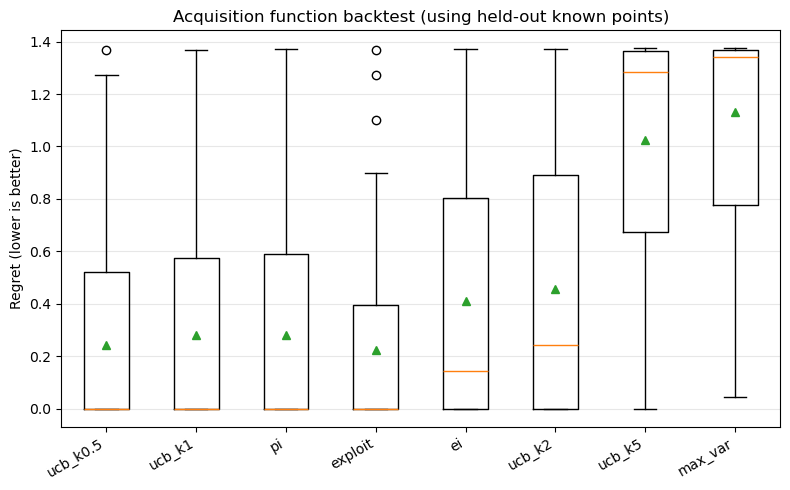

In [7]:
xi_raw = 0.01 * (y.max() - y.min())
backtest_configs = [
    {"name": "ucb_k0.5", "acquisition": "ucb", "kappa": 0.5},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k2",   "acquisition": "ucb", "kappa": 2.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "ei",       "acquisition": "ei",  "xi": xi_raw},
    {"name": "pi",       "acquisition": "pi",  "xi": xi_raw},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]
print(f"xi for the PI/EI rows: {xi_raw:.6f} (1% of the y spread)\n")

backtest_results = backtest_acquisitions(
    X, y, bounds, backtest_configs,
    n_repeats=50, seed_frac=0.5, maximize=True,
    gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
)
print_backtest_summary(backtest_results)

fig = plot_acquisition_backtest(backtest_results)
plt.show()

## Compare kappa values -- the deciding cell

Two views. First `compare_kappa_proposals`, unrestricted over all six axes, shown to demonstrate why the restriction is needed: it is free to move x1 and x2, and whatever it does with them is an optimiser artifact on a flat surface.

Then the restricted search over the live axes only, which is what the choice is made from. `kappa=0.25` is committed as the largest value whose proposal touches **no bound at all**.

Bound contact is reported in two categories, because they mean different things. **Upper** bounds come from `pad_fraction=1.0` doubling each axis and are arbitrary -- a coordinate pinned there means the padding is choosing it rather than the model. **Lower** bounds are all `0.0`, a real domain constraint, so a coordinate there is a genuine "as low as allowed" prediction. Lower contact would be acceptable; it simply isn't necessary here.

=== unrestricted over all 6 axes (shown to demonstrate the problem) ===


/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


   kappa |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
    0.25 | [0.   ,0.   ,0.968,0.225,0.405,0.735] |     1.3790 |     1.3738 |    0.0211 |          0.8727
     0.5 | [0.   ,0.   ,1.846,0.228,0.406,0.74 ] |     1.3867 |     1.3672 |    0.0391 |          1.6721
       1 | [0.   ,0.   ,1.846,0.237,0.411,0.774] |     1.4155 |     1.3394 |    0.0761 |          1.6726
       2 | [0.   ,0.   ,1.846,0.245,0.416,0.824] |     1.5256 |     1.2421 |    0.1418 |          1.6746
       5 | [0.   ,0.   ,1.846,0.248,0.419,0.947] |     2.1430 |     0.8920 |    0.2502 |          1.6855

what the unrestricted search does with the FLAT axes x[1, 2] (incumbent has [0.4917 0.2474]):
  kappa=0.25  flat-axis values [0.     0.9684]  <- arbitrary; the acquisition is flat along these
  kappa=0.5   flat-axis values [0.     1.8455]  <- arbitrary; the acquisition is flat along these


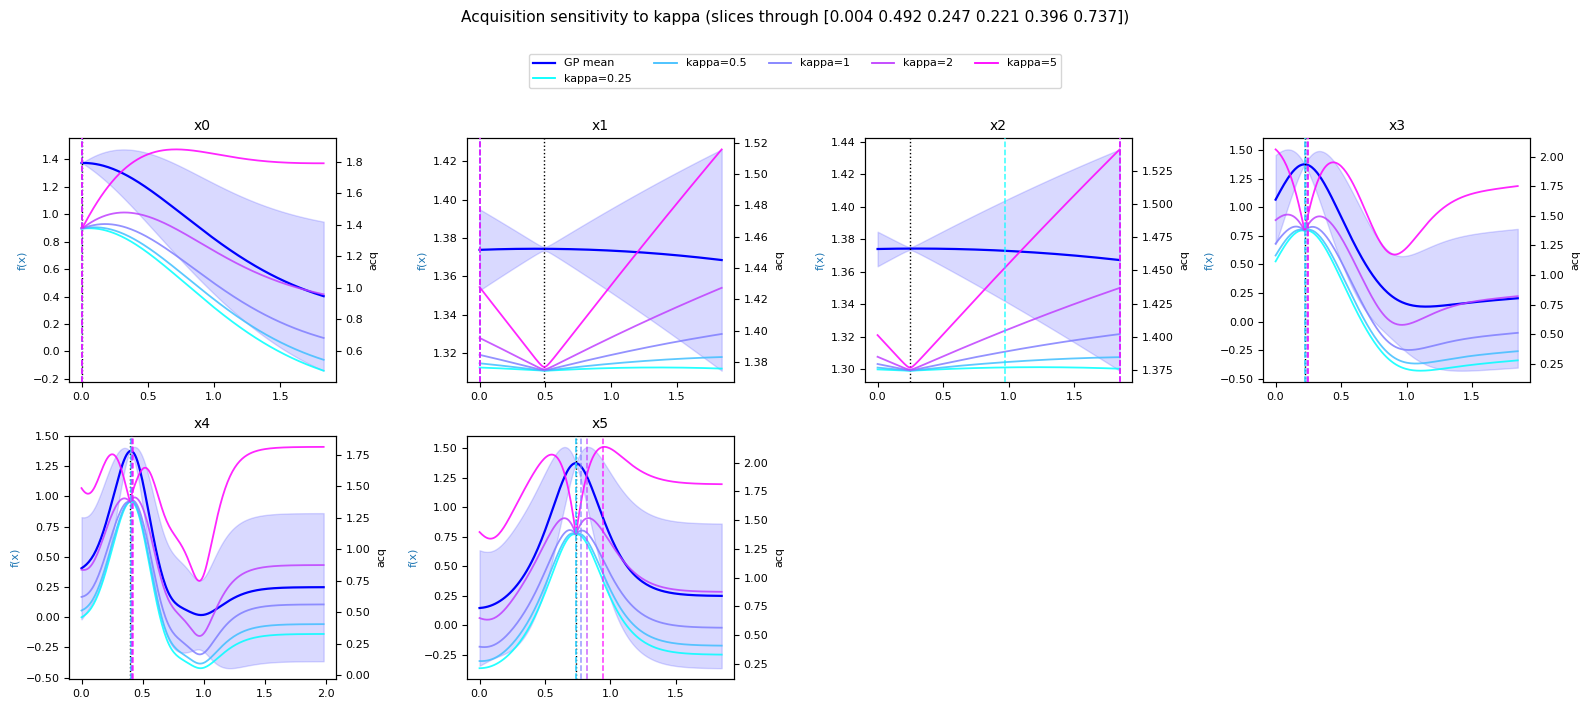


=== restricted to the live axes x[0, 3, 4, 5] (what the choice is made from) ===
 kappa |  pred mean |  pred std |    UPPER bnd |    lower bnd |    dist
     0 |   +1.37595 |   0.00348 |         none |         none |  0.0109
  0.25 |   +1.37377 |   0.01951 |         none |          [0] |  0.0153
   0.5 |   +1.36656 |   0.03876 |         none |          [0] |  0.0258
     1 |   +1.33862 |   0.07613 |         none |          [0] |  0.0488
     2 |   +1.24124 |   0.14186 |         none |          [0] |  0.0950
incumbent y = 1.374343

using kappa = 0.25, searching only x[0, 3, 4, 5]
chosen as the largest kappa whose proposal touches NO bound, upper or lower


In [8]:
def bound_report(p):
    """Upper-bound contact is a pad_fraction artifact; lower is the X >= 0 floor."""
    upper = [d for d in range(D) if np.isclose(p[d], bounds[d, 1])]
    lower = [d for d in range(D) if np.isclose(p[d], bounds[d, 0])]
    return upper, lower


print("=== unrestricted over all 6 axes (shown to demonstrate the problem) ===")
kappa_rows = compare_kappa_proposals(X, y, bounds, kappa_values=[0.25, 0.5, 1.0, 2.0, 5.0],
                                      maximize=True, n_restarts=40, random_state=0)
print_kappa_comparison(kappa_rows)
print("\nwhat the unrestricted search does with the FLAT axes"
      f" x{flat} (incumbent has {np.round(incumbent[flat], 4)}):")
for row in kappa_rows:
    print(f"  kappa={row['kappa']:<5g} flat-axis values {np.round(row['x_next'][flat], 4)}"
          f"  <- arbitrary; the acquisition is flat along these")

fig = plot_kappa_sensitivity(X, y, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()


def restricted_ucb(kappa, n_starts=80):
    """Maximise UCB over the live axes only, holding flat axes at the incumbent."""
    lo = bounds[live, 0]
    hi = bounds[live, 1]

    def neg(v):
        p = incumbent.copy()
        p[live] = v
        return -ucb_acquisition(normalize(p.reshape(1, -1), bounds), gp_check,
                                 kappa=kappa, maximize=True)[0]

    best_val, best_v = np.inf, None
    rng = np.random.default_rng(0)
    for start in rng.uniform(lo, hi, size=(n_starts, len(live))):
        res = minimize(neg, start, method="L-BFGS-B", bounds=list(zip(lo, hi)))
        if res.fun < best_val:
            best_val, best_v = res.fun, res.x
    p = incumbent.copy()
    p[live] = best_v
    m, s = gp_check.predict(normalize(p.reshape(1, -1), bounds), return_std=True)
    return p, m[0], s[0]


print(f"\n=== restricted to the live axes x{live} (what the choice is made from) ===")
print(f"{'kappa':>6} | {'pred mean':>10} | {'pred std':>9} | {'UPPER bnd':>12}"
      f" | {'lower bnd':>12} | {'dist':>7}")
for k in [0.0, 0.25, 0.5, 1.0, 2.0]:
    p, m, s = restricted_ucb(k)
    up, lo_ = bound_report(p)
    print(f"{k:6g} | {m:+10.5f} | {s:9.5f} | {str(up) if up else 'none':>12}"
          f" | {str(lo_) if lo_ else 'none':>12} | {np.linalg.norm(p - incumbent):7.4f}")
print(f"incumbent y = {y.max():.6f}")

# Committed choice -- reused by the proposal, the slice plot, and the diagnostics
# replay below, so they can't silently drift apart.
KAPPA = 0.25
print(f"\nusing kappa = {KAPPA}, searching only x{live}")
print("chosen as the largest kappa whose proposal touches NO bound, upper or lower")

## Propose the next point

The live axes come from the restricted UCB search; x1 and x2 are held at the incumbent because the acquisition is flat along them.

Expect a small step (~0.06). That is deliberate: last week's large extrapolation returned the worst value on record, the model is well calibrated near the data, and the incumbent is a peak the model cannot reproduce when it is held out -- so mapping its immediate neighbourhood is the informative move.

In [9]:
x_next, mu_next, sigma_next = restricted_ucb(KAPPA, n_starts=150)
gp = gp_check

print(f"--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu_next:.6f}, predicted std: {sigma_next:.6f}")
print(f"current best observed y: {y.max():.6f}"
      f"  -> predicted improvement: {mu_next - y.max():+.6f}")
print(f"flat axes x{flat} held at the incumbent:"
      f" {np.allclose(x_next[flat], incumbent[flat])}")

up, lo = bound_report(x_next)
print("\non UPPER bound (pad_fraction artifact -- bad):", up or "none")
if up:
    print("*** pad_fraction is choosing those coordinates, not the model.")
    print("    Lower kappa until the proposal comes off the upper bounds. ***")
print("on lower bound (X >= 0 floor -- legitimate):", lo or "none")

outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("outside the observed range on its own axis:", outside or "none")
if hull is not None:
    print(f"inside the convex hull: {bool(hull.find_simplex(x_next) >= 0)}"
          "  (nearly vacuous at D=6 -- see above)")

print(f"\ndistance from the incumbent: {np.linalg.norm(x_next - incumbent):.6f}")
print("for comparison, the week-2 proposal was"
      f" {np.linalg.norm(new_X[0] - X_initial[np.argmax(y_initial)]):.4f} from the"
      " then-incumbent and returned the worst y on record; the week-3 proposal"
      f" was {np.linalg.norm(new_X[-1] - X_initial[np.argmax(y_initial)]):.4f}"
      " away and returned the best")
print("\nnearest 3 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:3]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  y={y[i]:+.6f}  X={np.round(X[i], 3)}")

--- Next point to evaluate (bounds shape (6, 2)) ---
x_next: [0.       0.491672 0.247422 0.229847 0.406692 0.743286]
0.874**2 * Matern(length_scale=[0.593, 10, 10, 0.193, 0.103, 0.131], nu=2.5) + WhiteKernel(noise_level=1e-06)
GP predicted mean: 1.373774, predicted std: 0.019511
current best observed y: 1.374343  -> predicted improvement: -0.000569
flat axes x[1, 2] held at the incumbent: True

on UPPER bound (pad_fraction artifact -- bad): none
on lower bound (X >= 0 floor -- legitimate): [0]
outside the observed range on its own axis: [0]
inside the convex hull: False  (nearly vacuous at D=6 -- see above)

distance from the incumbent: 0.015313
for comparison, the week-2 proposal was 1.8343 from the then-incumbent and returned the worst y on record; the week-3 proposal was 0.0595 away and returned the best

nearest 3 observations to x_next:
  dist=0.0153  y=+1.374343  X=[0.004 0.492 0.247 0.221 0.396 0.737]
  dist=0.0619  y=+1.364968  X=[0.058 0.492 0.247 0.218 0.42  0.731]
  dist=0.4

## Visualise the GP and acquisition function via 1D slices

Each panel holds the other five dimensions fixed at the current best observed point and sweeps one dimension. Dotted line is the fixed centre, dashed red is the proposed `x_next`, green is UCB.

Expect the **x1 and x2 panels to be essentially flat lines** -- their y-axis range is about 0.006 against roughly 1.3 for the other four. That flatness is the model, not a plotting bug, and it is exactly why those two coordinates are pinned at the incumbent rather than optimised.

The x0, x3, x4 and x5 panels should each show structure on a comparable scale, which is why the search covers all four rather than reducing to one axis.

This is a *partial* view: it shows the GP along each axis near the best point, not interactions between dimensions.

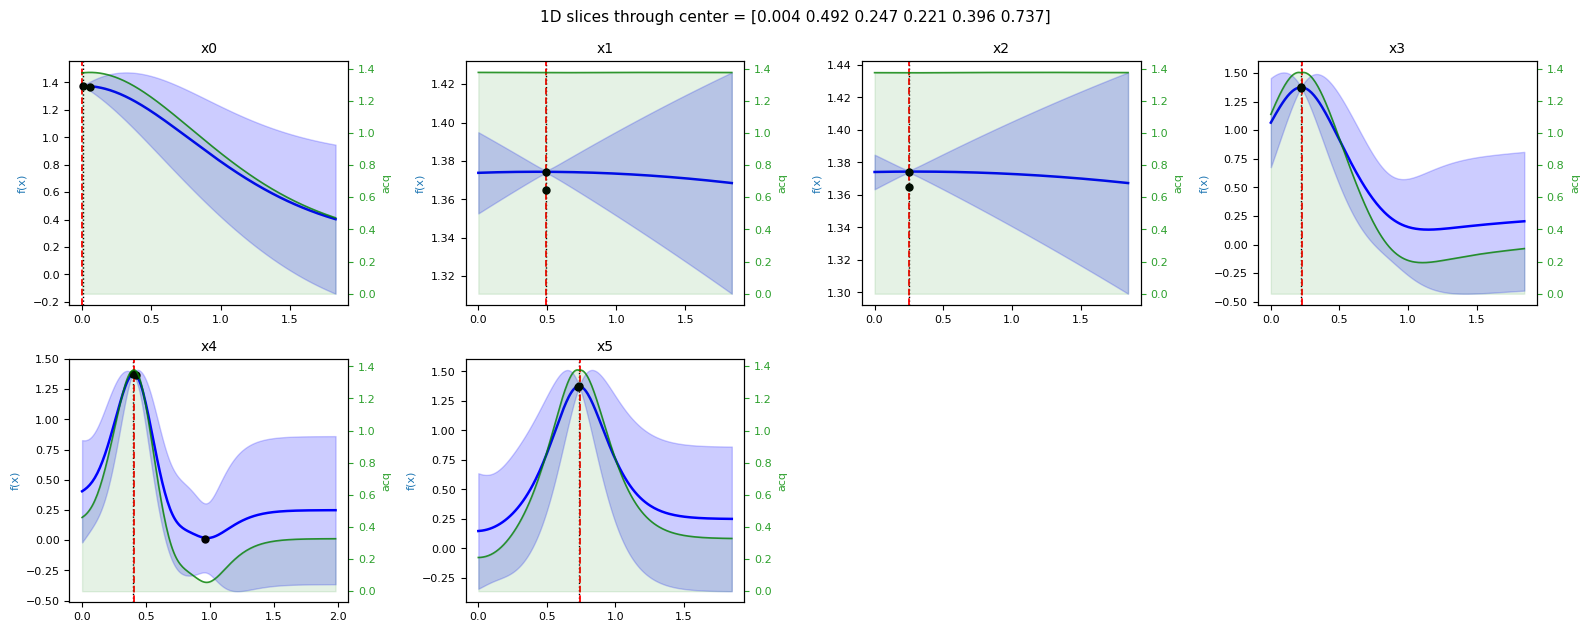

In [10]:
fig = plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate model: leave-one-out calibration

Refits the GP once per observation, leaving it out, and predicts it from the rest. At D=6 this is the main way to judge the surrogate.

**The key thing to read here is which point is worst-predicted, and it should be the incumbent.** Held out, the best observation is predicted at roughly `0.203 +/- 0.086` against a true `1.365` -- about a 13.5 sigma miss. The peak therefore rests on a single measurement the rest of the data gives no reason to expect.

That is not an argument that the model is broken -- overall coverage is reasonable -- but it is the argument for spending this week close to the incumbent. Either the peak is real and its neighbourhood will show it, or it isn't and we find that out cheaply.

/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaus

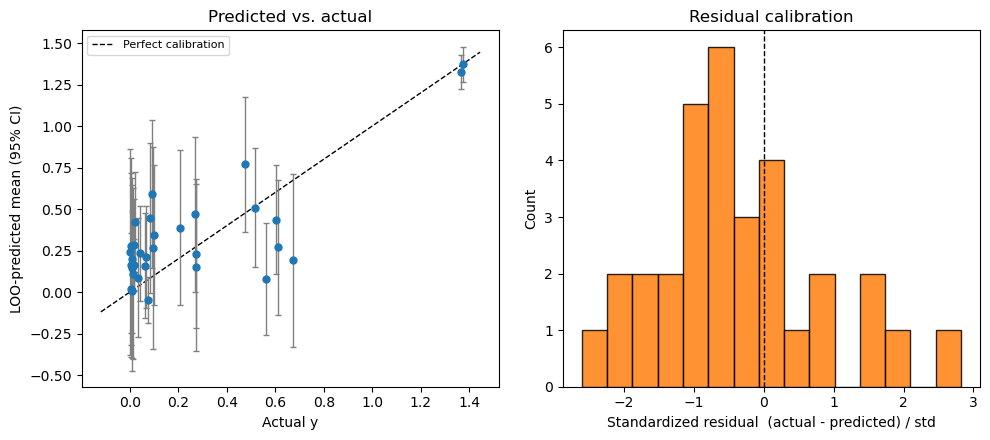

points inside their own 95% LOO interval: 29/32
worst-predicted: index 7 -> true 0.092645, predicted 0.591491 (std 0.226970) = -2.2 sigma
is that the incumbent (the best observation)? False
is it the newly collected point? False


In [11]:
pred_mean, pred_std = loo_predictions(X, y, bounds, gp_kwargs={"n_restarts_optimizer": 20})
fig = plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")
worst = int(np.argmax(np.abs(y - pred_mean)))
print(f"worst-predicted: index {worst} -> true {y[worst]:.6f},"
      f" predicted {pred_mean[worst]:.6f} (std {pred_std[worst]:.6f})"
      f" = {(y[worst] - pred_mean[worst]) / pred_std[worst]:+.1f} sigma")
print("is that the incumbent (the best observation)?", worst == int(np.argmax(y)))
print("is it the newly collected point?", worst == n_initial)

## Iteration diagnostics

`compute_iteration_diagnostics` replays the ordered `X`/`y` to reconstruct what the acquisition value, GP hyperparameters, and domain-wide uncertainty were at each past proposal -- no persisted log involved.

**`domain_grid_n` MUST be lowered at this dimensionality.** Its `domain_mean_std` field averages the posterior std over a grid of `domain_grid_n ** D` points, and the default `domain_grid_n=40` means `40**6 = 4.1e9` points -- roughly **197 GB**, which kills the kernel outright. The cell below sizes the grid so the point count stays near 200,000 whatever `D` is, giving `domain_grid_n=7` here. `domain_mean_std` is therefore a coarse estimate: fine for comparing iterations within this notebook, not comparable against a run with a different grid.

Two further caveats. The setting is taken from `KAPPA` so it can't drift from the proposal -- but the recorded observation came from the old sweep's `pi`/`xi=0.01`, so its replayed acquisition value describes a decision never made that way; treat that column as meaningless until the history is UCB throughout. And it assumes row order is true chronological order.

`plot_bo_diagnostics` is skipped (it hard-codes a 2D scatter panel and this is 6D); the trend plots below are dimension-agnostic and gated on having a few completed iterations.

In [12]:
# compute_iteration_diagnostics builds a domain_grid_n ** D grid. The default of
# 40 is 40**6 = 4.1e9 points (~197 GB) at D=6 and WILL kill the kernel. Size it
# so the grid stays ~200k points whatever D is.
DOMAIN_GRID_N = max(3, int(200_000 ** (1.0 / D)))
print(f"domain_grid_n = {DOMAIN_GRID_N} -> {DOMAIN_GRID_N ** D:,} grid points"
      f" (the default 40 would be {40 ** D:,})")

history = None
if len(new_y) == 0:
    print("\nNo observations beyond the initial batch yet -- nothing to replay.")
    print("Best y so far:", y.max())
else:
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                             acquisition="ucb", kappa=KAPPA, maximize=True,
                                             domain_grid_n=DOMAIN_GRID_N)
    print("\nBest y so far:", np.nanmax(history["y"]))
    print("completed iterations beyond the initial batch:", len(new_y))

    if len(new_y) >= 3:
        for plot_fn in (plot_convergence, plot_acquisition_decay,
                        plot_uncertainty_shrinkage, plot_step_distance):
            plot_fn(history)
            plt.show()
    else:
        print(f"\nOnly {len(new_y)} completed iteration(s) -- need at least 3 for the trend\n"
              "plots to say anything. Skipping them; the raw fields are below.")

domain_grid_n = 7 -> 117,649 grid points (the default 40 would be 4,096,000,000)


/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Best y so far: 1.3743434016209042
completed iterations beyond the initial batch: 2

Only 2 completed iteration(s) -- need at least 3 for the trend
plots to say anything. Skipping them; the raw fields are below.


/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/nicg/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Raw diagnostic fields

In [13]:
if history is not None:
    print("y:", np.round(history["y"], 6))
    print("\niteration:", history["iteration"])
    print("\nacq_value (NaN = initial batch; see the caveat above):", history["acq_value"])
    print("\npred_mean at proposal time:", history["pred_mean"])
    print("\ndomain_mean_std:", history["domain_mean_std"])

y: [6.044330e-01 5.627530e-01 7.503000e-03 6.142400e-02 2.730470e-01
 8.374700e-02 1.364968e+00 9.264500e-02 1.787000e-02 3.356500e-02
 7.351600e-02 2.063100e-01 8.826000e-03 2.684000e-01 6.115260e-01
 1.479800e-02 2.748930e-01 6.676300e-02 4.211800e-02 2.701000e-03
 1.820900e-02 7.016000e-03 1.005070e-01 4.753960e-01 6.751420e-01
 5.164570e-01 3.777000e-03 3.134000e-03 2.134300e-02 9.541100e-02
 3.090000e-04 1.374343e+00]

iteration: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 2.]

acq_value (NaN = initial batch; see the caveat above): [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
 0.28456646 1.38556101]

pred_mean at proposal time: [       nan       

In [14]:
# The proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X: a 6-dp copy of function 4's proposal rounded 4e-7 outside its
# own upper bound and tripped validate_bounds_consistency.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.000000-0.491672-0.247422-0.229847-0.406692-0.743286

full precision (use for next week's new_X):
0.0-0.491672-0.247422-0.22984697122907258-0.40669179743832057-0.7432861211974007
